In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import joblib
import warnings 
warnings.filterwarnings("ignore")

In [32]:
df = pd.read_csv("../Datasets/kidney_disease.csv")

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [33]:
df.shape

(400, 25)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    object 
 19  dm      398 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399 non-null    object 
 22  pe

In [35]:
df.describe(include='all')

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
count,391.000000,388.000000,353.000000,354.000000,351.000000,248,335,396,396,356.000000,...,329.000000,294.000000,269.000000,398,398,398,399,399,399,400
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,NaN,...,NaN,NaN,NaN,2,3,2,2,2,2,3
top,NaN,NaN,NaN,NaN,NaN,normal,normal,notpresent,notpresent,NaN,...,NaN,NaN,NaN,no,no,no,good,no,no,ckd
freq,NaN,NaN,NaN,NaN,NaN,201,259,354,374,NaN,...,NaN,NaN,NaN,251,260,364,317,323,339,248
mean,51.483376,76.469072,1.017408,1.016949,0.450142,NaN,NaN,NaN,NaN,148.036517,...,38.884498,8406.122449,4.707435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,17.169714,13.683637,0.005717,1.352679,1.099191,NaN,NaN,NaN,NaN,79.281714,...,8.990105,2944.474190,1.025323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2.000000,50.000000,1.005000,0.000000,0.000000,NaN,NaN,NaN,NaN,22.000000,...,9.000000,2200.000000,2.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,42.000000,70.000000,1.010000,0.000000,0.000000,NaN,NaN,NaN,NaN,99.000000,...,32.000000,6500.000000,3.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,55.000000,80.000000,1.020000,0.000000,0.000000,NaN,NaN,NaN,NaN,121.000000,...,40.000000,8000.000000,4.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,64.500000,80.000000,1.020000,2.000000,0.000000,NaN,NaN,NaN,NaN,163.000000,...,45.000000,9800.000000,5.400000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
nulls = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage":
    round(df.isnull().mean()*100,2)
})

nulls.sort_values(
    by="Missing",
    ascending=False
)

,Missing,Percentage
rbc,152,38.00
rbcc,131,32.75
wbcc,106,26.50
pot,88,22.00
sod,87,21.75
pcv,71,17.75
pc,65,16.25
hemo,52,13.00
su,49,12.25
sg,47,11.75


In [38]:
df['class'].unique()

array(['ckd', 'ckd\t', 'notckd'], dtype=object)

In [39]:
df['class'] = df['class'].str.strip()

df['class'] = df['class'].replace({'ckd': 1,'notckd': 0})

df['class'] = df['class'].astype(int)

In [41]:
print(df['class'].unique())
print(df['class'].value_counts())
print(df['class'].isna().sum())

[1 0]
class
1    250
0    150
Name: count, dtype: int64
0


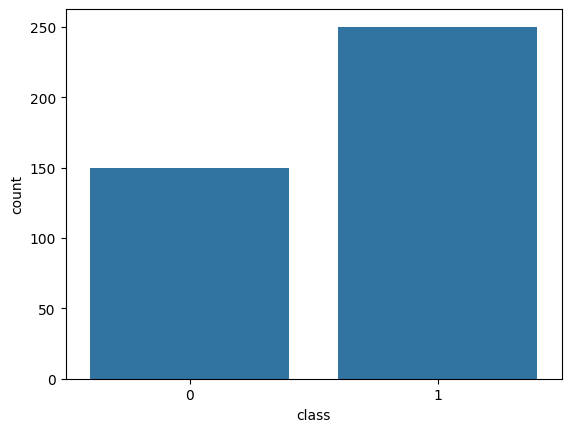

In [42]:
sns.countplot(x='class',data=df)

plt.show()

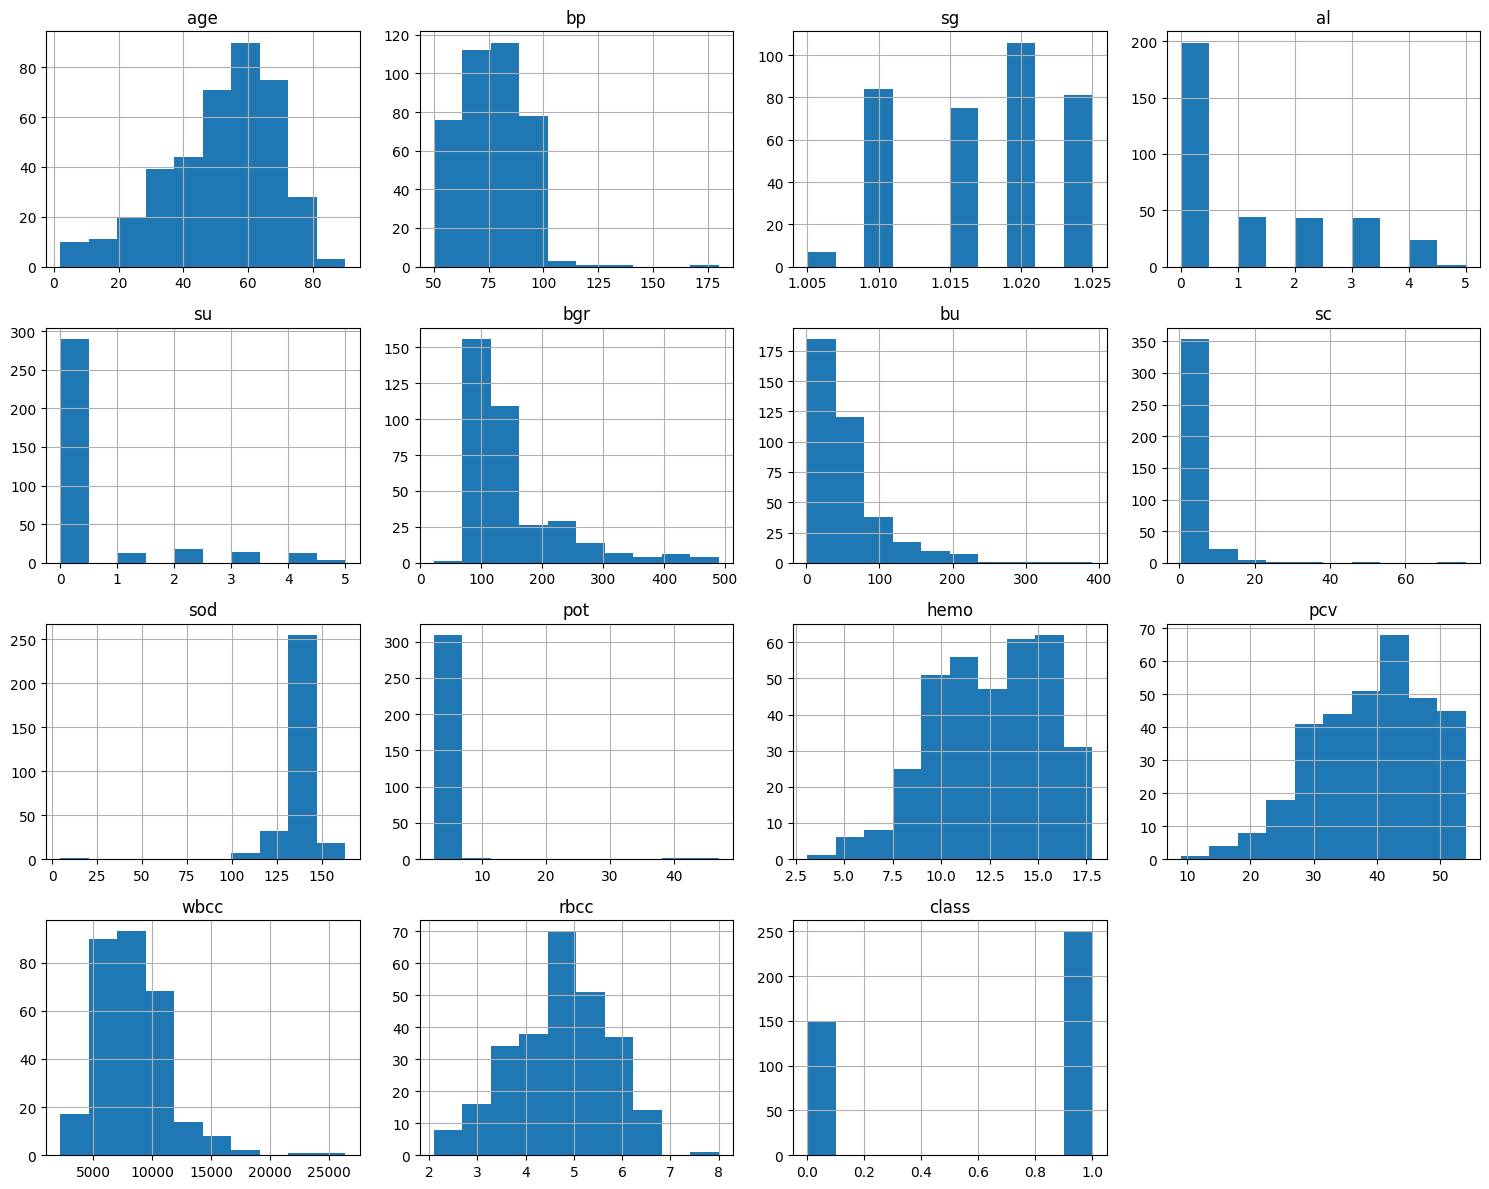

In [43]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,12))

plt.tight_layout()
plt.show()

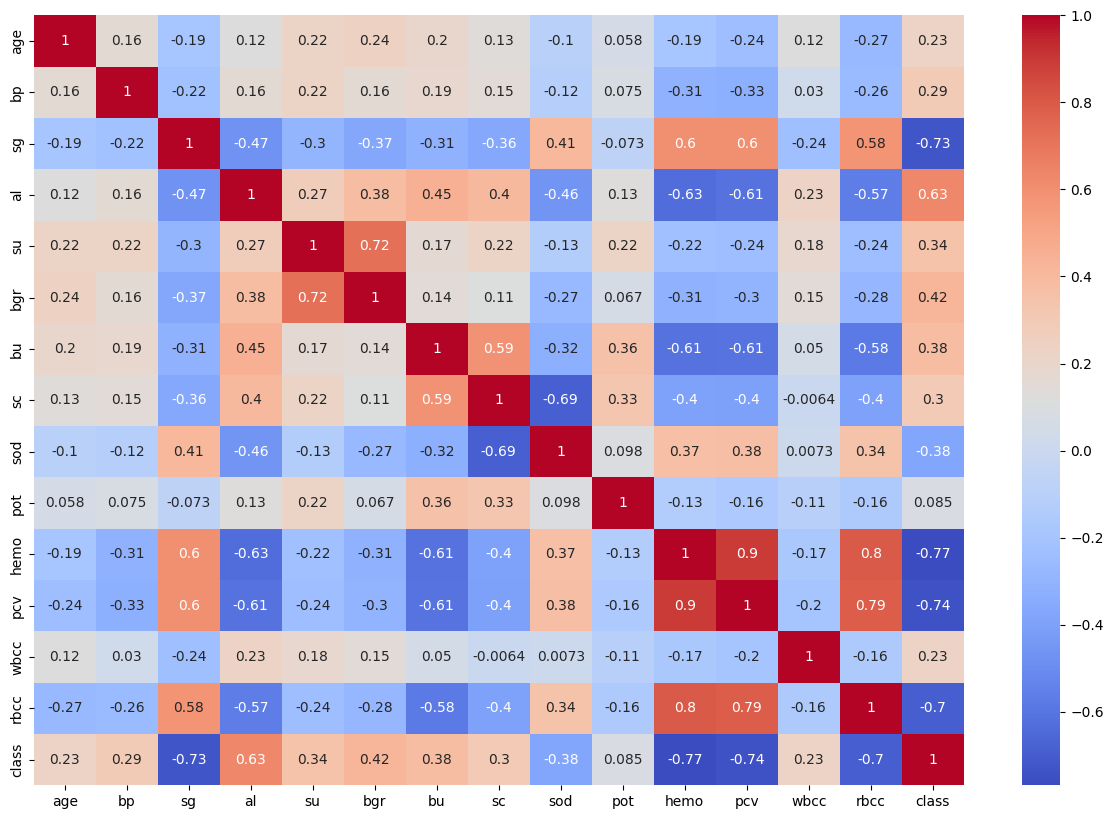

In [44]:
plt.figure(figsize=(15,10))

sns.heatmap(df[num_cols].corr(),cmap='coolwarm',annot=True)

plt.show()

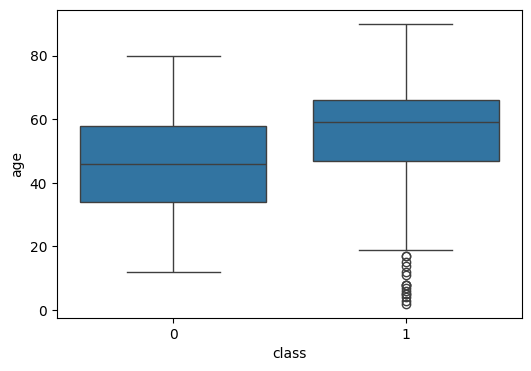

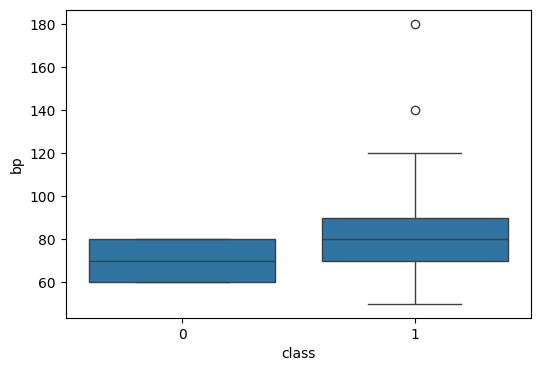

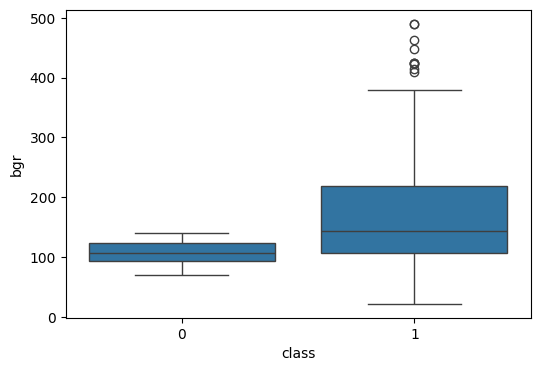

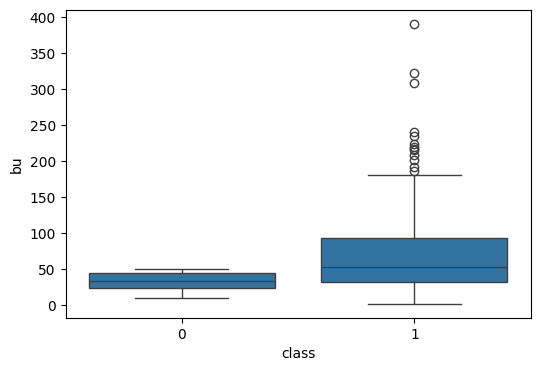

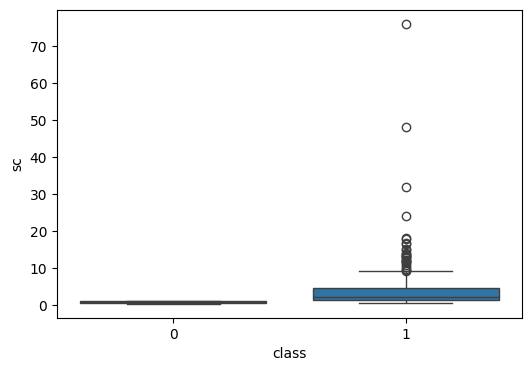

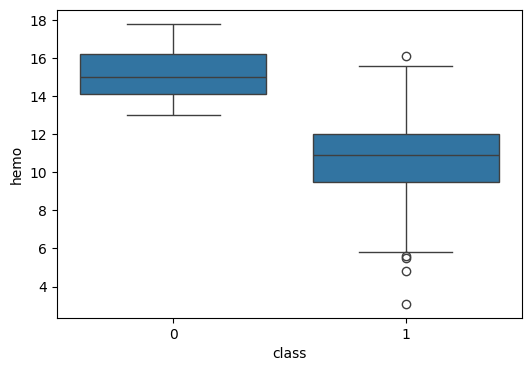

In [45]:
for col in ['age','bp','bgr','bu','sc','hemo']:
    
    plt.figure(figsize=(6,4))

    sns.boxplot(x='class',y=col,data=df)

    plt.show()

In [52]:
X = df.drop("class",axis=1)

y = df["class"]

In [53]:
cat_cols = X.select_dtypes(include='object').columns

num_cols = X.select_dtypes(exclude='object').columns

In [54]:
numeric_transformer = Pipeline([
    ('imputer',impleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

In [55]:
categorical_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

In [56]:
preprocessor = ColumnTransformer([
    ('num',numeric_transformer,num_cols),
    ('cat',categorical_transformer,cat_cols)
])

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [58]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

lr_pipeline.fit(X_train,y_train)

pred_lr = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test,pred_lr)

print(lr_acc)

0.9875


In [59]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',RandomForestClassifier(n_estimators=300,random_state=42))
])

rf_pipeline.fit(X_train,y_train)

pred_rf = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test,pred_rf)

print(rf_acc)

1.0


In [60]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',XGBClassifier(
         n_estimators=500,
         max_depth=4,
         learning_rate=0.03,
         subsample=0.8,
         colsample_bytree=0.8,
         random_state=42,
         eval_metric='logloss'
     ))
])

xgb_pipeline.fit(X_train, y_train)

pred_xgb = xgb_pipeline.predict(X_test)

xgb_acc = accuracy_score(y_test,pred_xgb)

print(xgb_acc)

1.0


In [61]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[lr_acc,rf_acc,xgb_acc]
})

results.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy
1,Random Forest,1.0000
2,XGBoost,1.0000
0,Logistic Regression,0.9875


In [62]:
joblib.dump(
    xgb_pipeline,
    "kidney_model.pkl"
)

['kidney_model.pkl']